---

# [Third Party Tools](https://google.github.io/adk-docs/tools/third-party-tools/)
## `1. Using LangChain Tools`
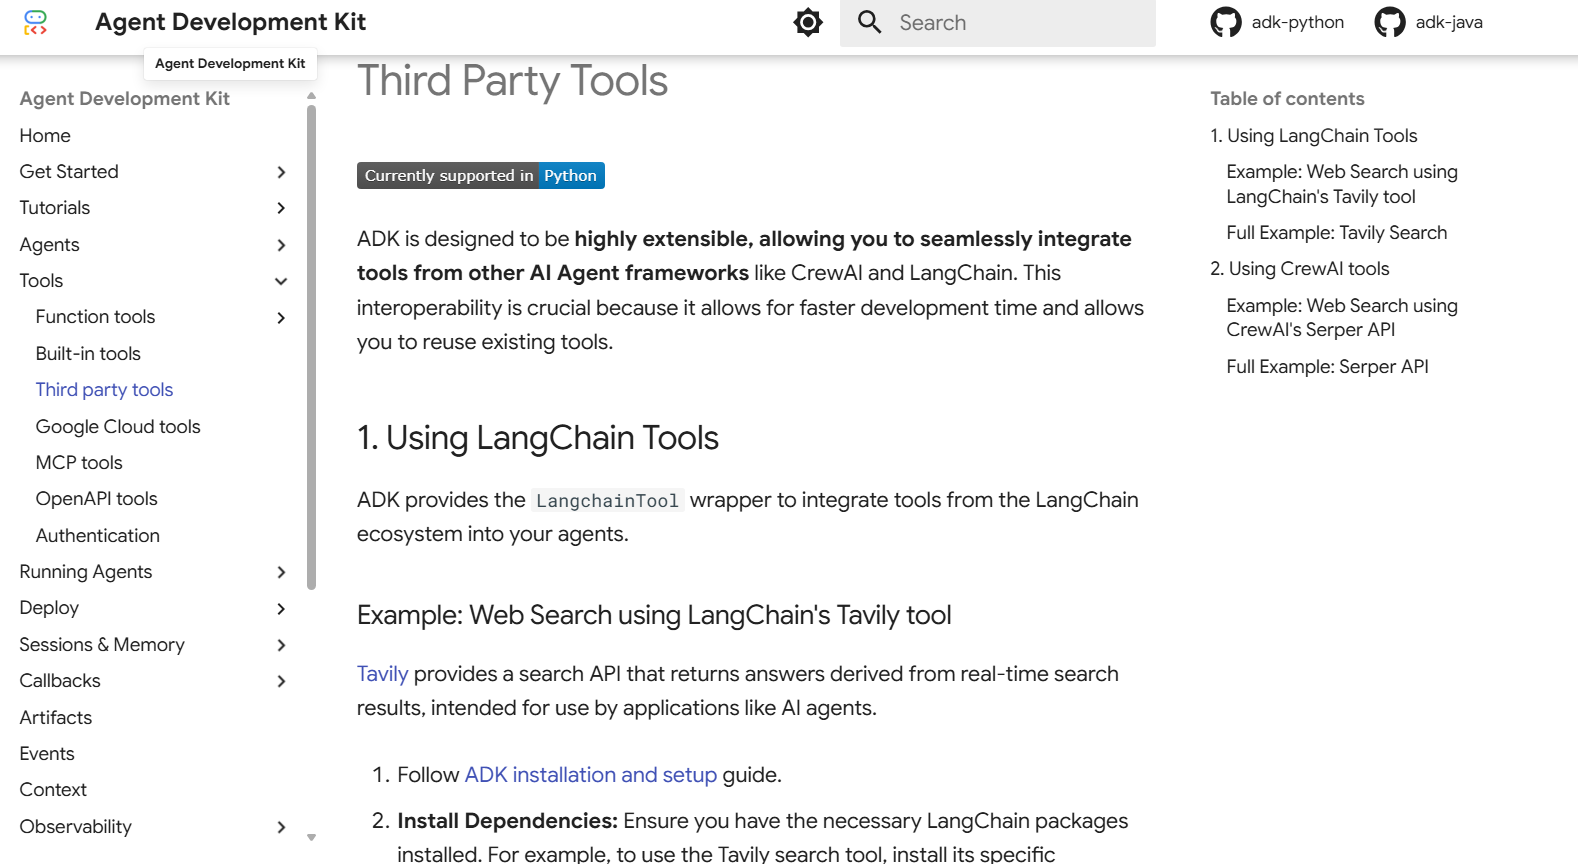 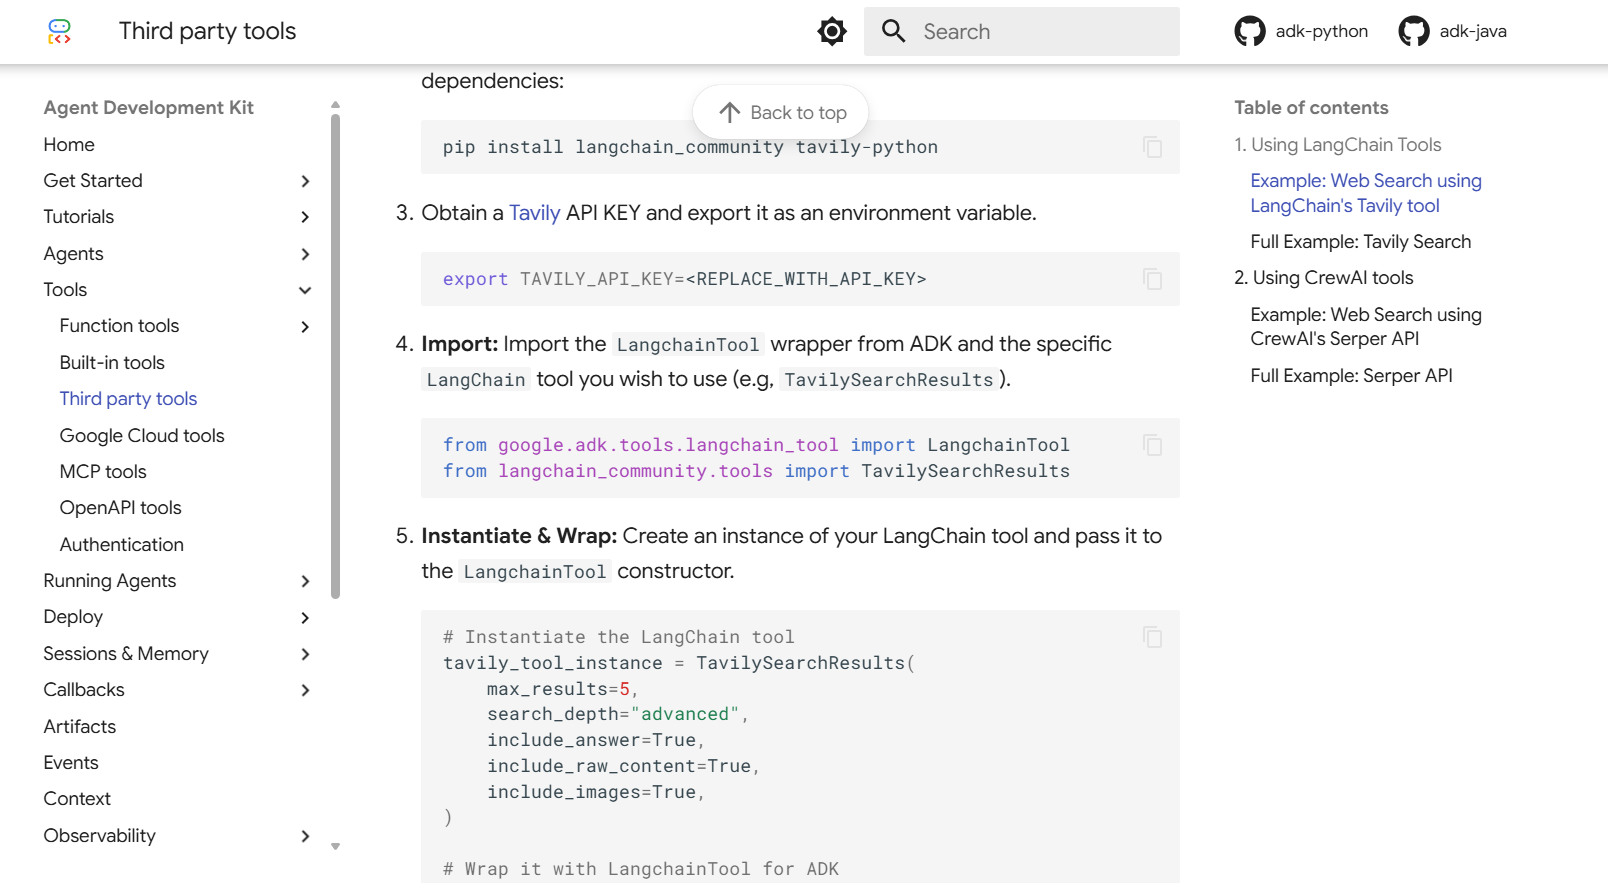 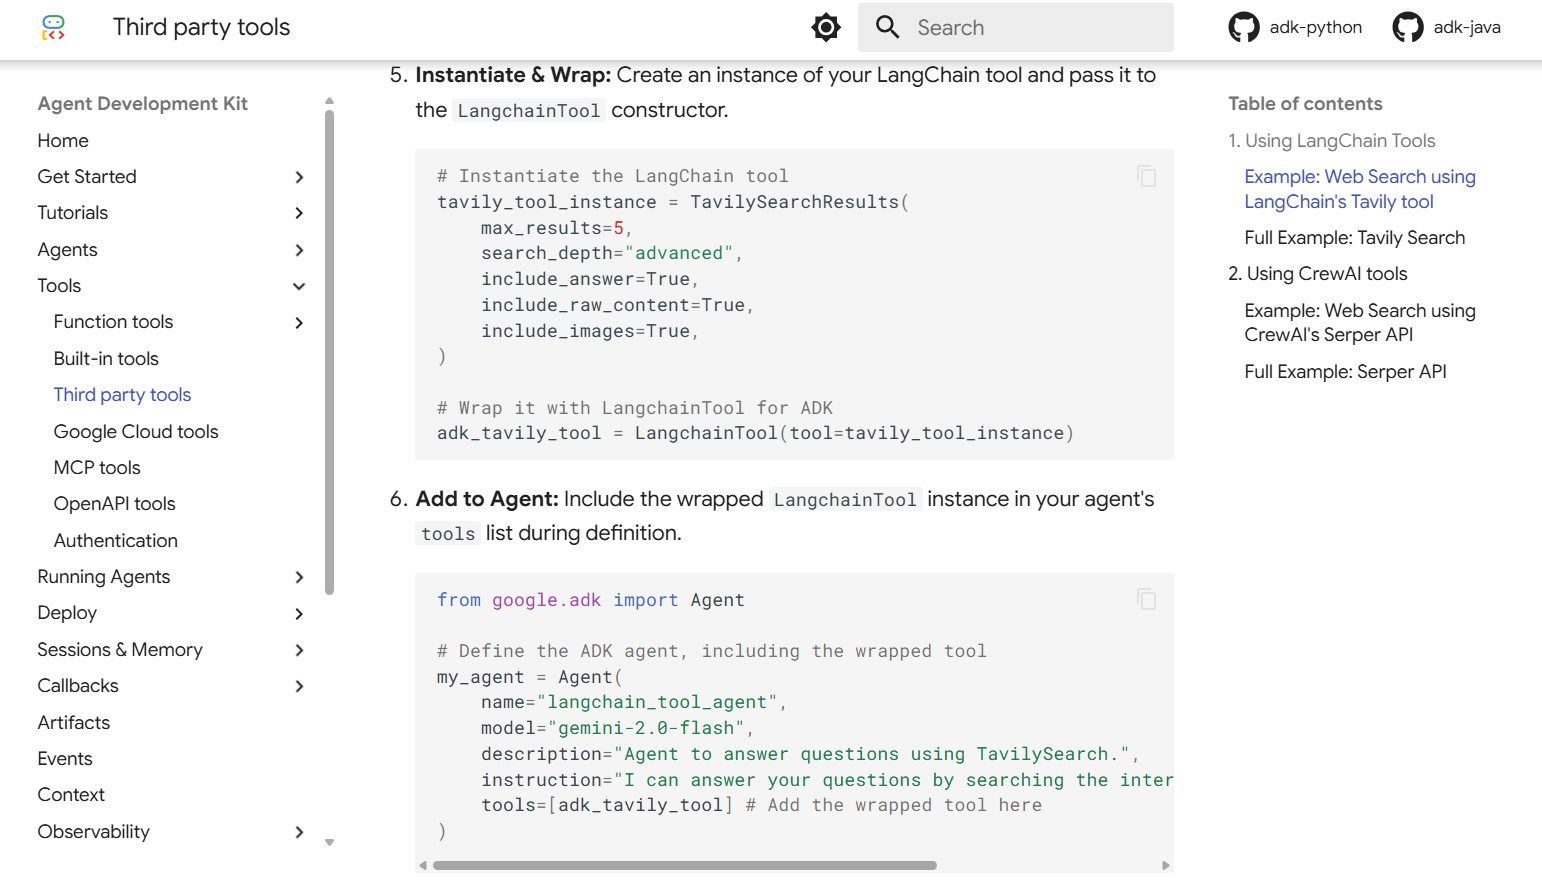

---

### `Full Example: Tavily Search`
> Here's the full code combining the steps above to create and run an agent using the LangChain Tavily search tool.

```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import os
from google.adk import Agent, Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools.langchain_tool import LangchainTool
from google.genai import types
from langchain_community.tools import TavilySearchResults

# Ensure TAVILY_API_KEY is set in your environment
if not os.getenv("TAVILY_API_KEY"):
    print("Warning: TAVILY_API_KEY environment variable not set.")

APP_NAME = "news_app"
USER_ID = "1234"
SESSION_ID = "session1234"

# Instantiate LangChain tool
tavily_search = TavilySearchResults(
    max_results=5,
    search_depth="advanced",
    include_answer=True,
    include_raw_content=True,
    include_images=True,
)

# Wrap with LangchainTool
adk_tavily_tool = LangchainTool(tool=tavily_search)

# Define Agent with the wrapped tool
my_agent = Agent(
    name="langchain_tool_agent",
    model="gemini-2.0-flash",
    description="Agent to answer questions using TavilySearch.",
    instruction="I can answer your questions by searching the internet. Just ask me anything!",
    tools=[adk_tavily_tool] # Add the wrapped tool here
)

async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=my_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner

# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("stock price of GOOG")
```

---

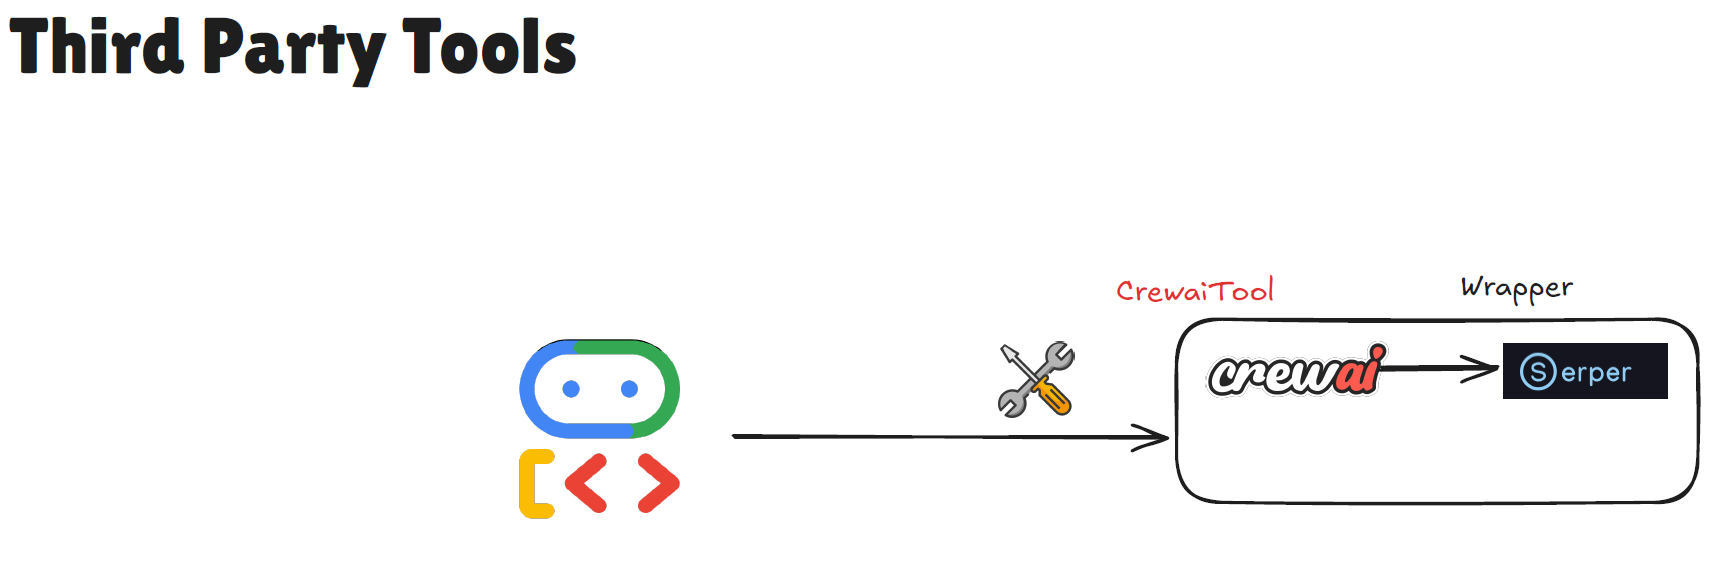

## `2. Using CrewAI tools`
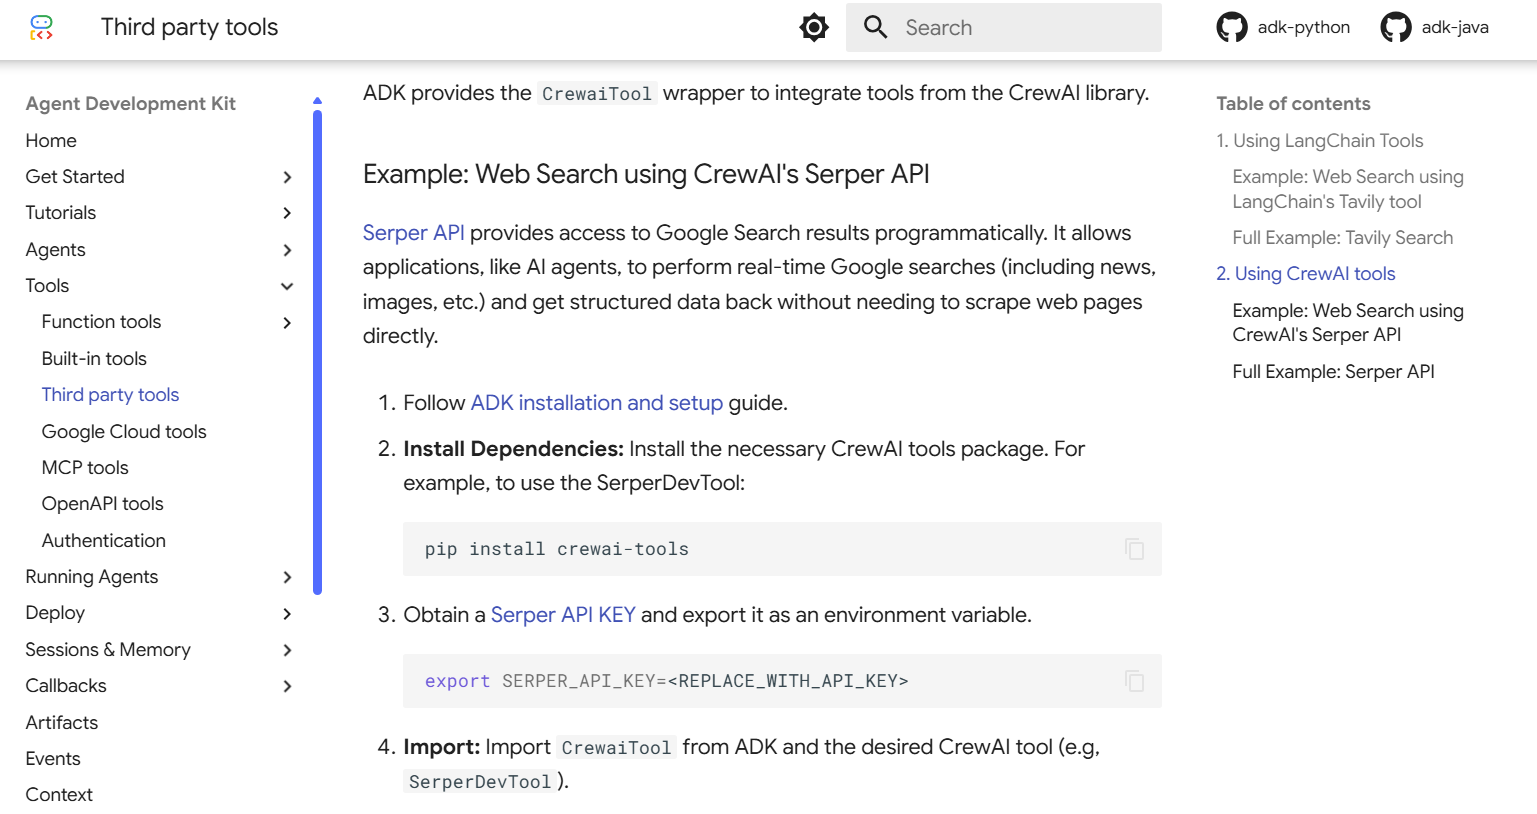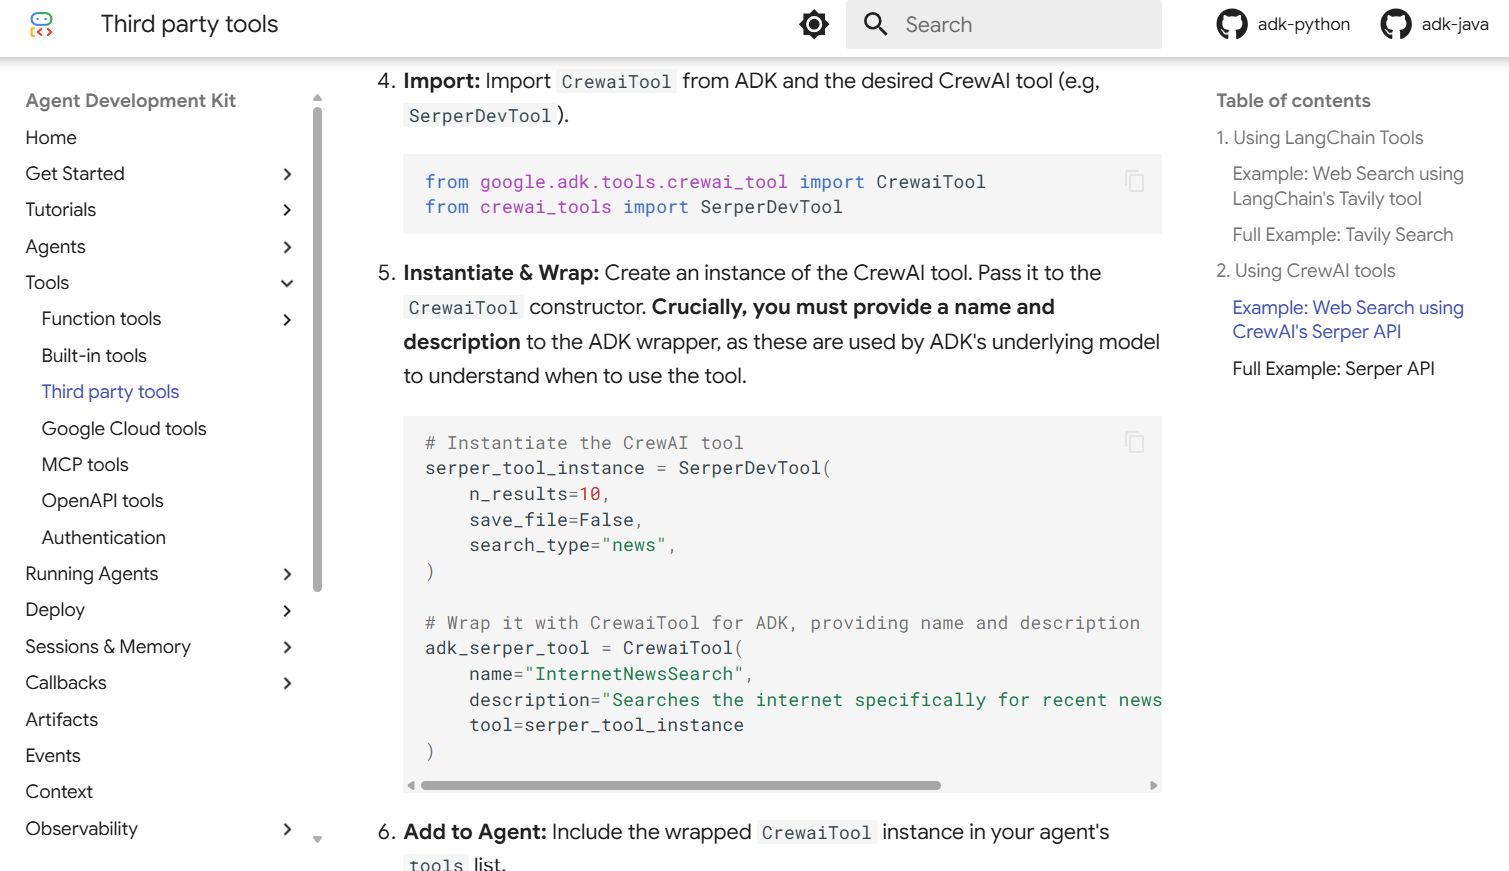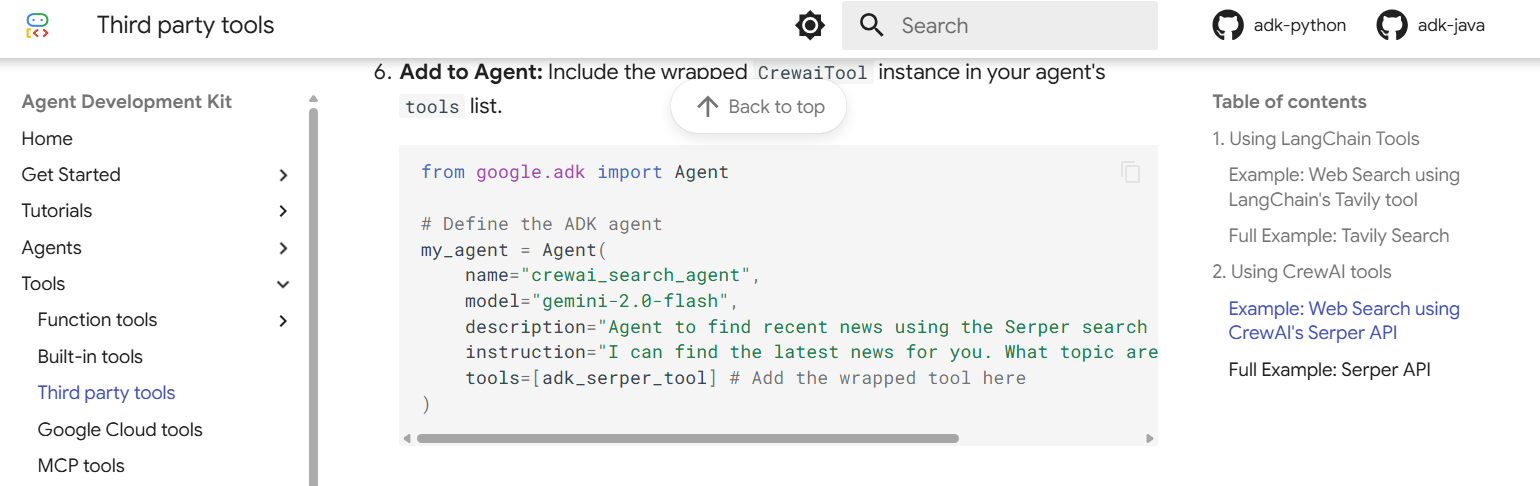

### `Full Example: Serper API`
> Here's the full code combining the steps above to create and run an agent using the CrewAI Serper API search tool.
```Python
# Copyright 2025 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

import os
from google.adk import Agent, Runner
from google.adk.sessions import InMemorySessionService
from google.adk.tools.crewai_tool import CrewaiTool
from google.genai import types
from crewai_tools import SerperDevTool


# Constants
APP_NAME = "news_app"
USER_ID = "user1234"
SESSION_ID = "1234"

# Ensure SERPER_API_KEY is set in your environment
if not os.getenv("SERPER_API_KEY"):
    print("Warning: SERPER_API_KEY environment variable not set.")

serper_tool_instance = SerperDevTool(
    n_results=10,
    save_file=False,
    search_type="news",
)

adk_serper_tool = CrewaiTool(
    name="InternetNewsSearch",
    description="Searches the internet specifically for recent news articles using Serper.",
    tool=serper_tool_instance
)

serper_agent = Agent(
    name="basic_search_agent",
    model="gemini-2.0-flash",
    description="Agent to answer questions using Google Search.",
    instruction="I can answer your questions by searching the internet. Just ask me anything!",
    # Add the Serper tool
    tools=[adk_serper_tool]
)

# Session and Runner
async def setup_session_and_runner():
    session_service = InMemorySessionService()
    session = await session_service.create_session(app_name=APP_NAME, user_id=USER_ID, session_id=SESSION_ID)
    runner = Runner(agent=serper_agent, app_name=APP_NAME, session_service=session_service)
    return session, runner


# Agent Interaction
async def call_agent_async(query):
    content = types.Content(role='user', parts=[types.Part(text=query)])
    session, runner = await setup_session_and_runner()
    events = runner.run_async(user_id=USER_ID, session_id=SESSION_ID, new_message=content)

    async for event in events:
        if event.is_final_response():
            final_response = event.content.parts[0].text
            print("Agent Response: ", final_response)

# Note: In Colab, you can directly use 'await' at the top level.
# If running this code as a standalone Python script, you'll need to use asyncio.run() or manage the event loop.
await call_agent_async("what's the latest news on AI Agents?")
```

<hr>

### `crew-ai-tool-agent`
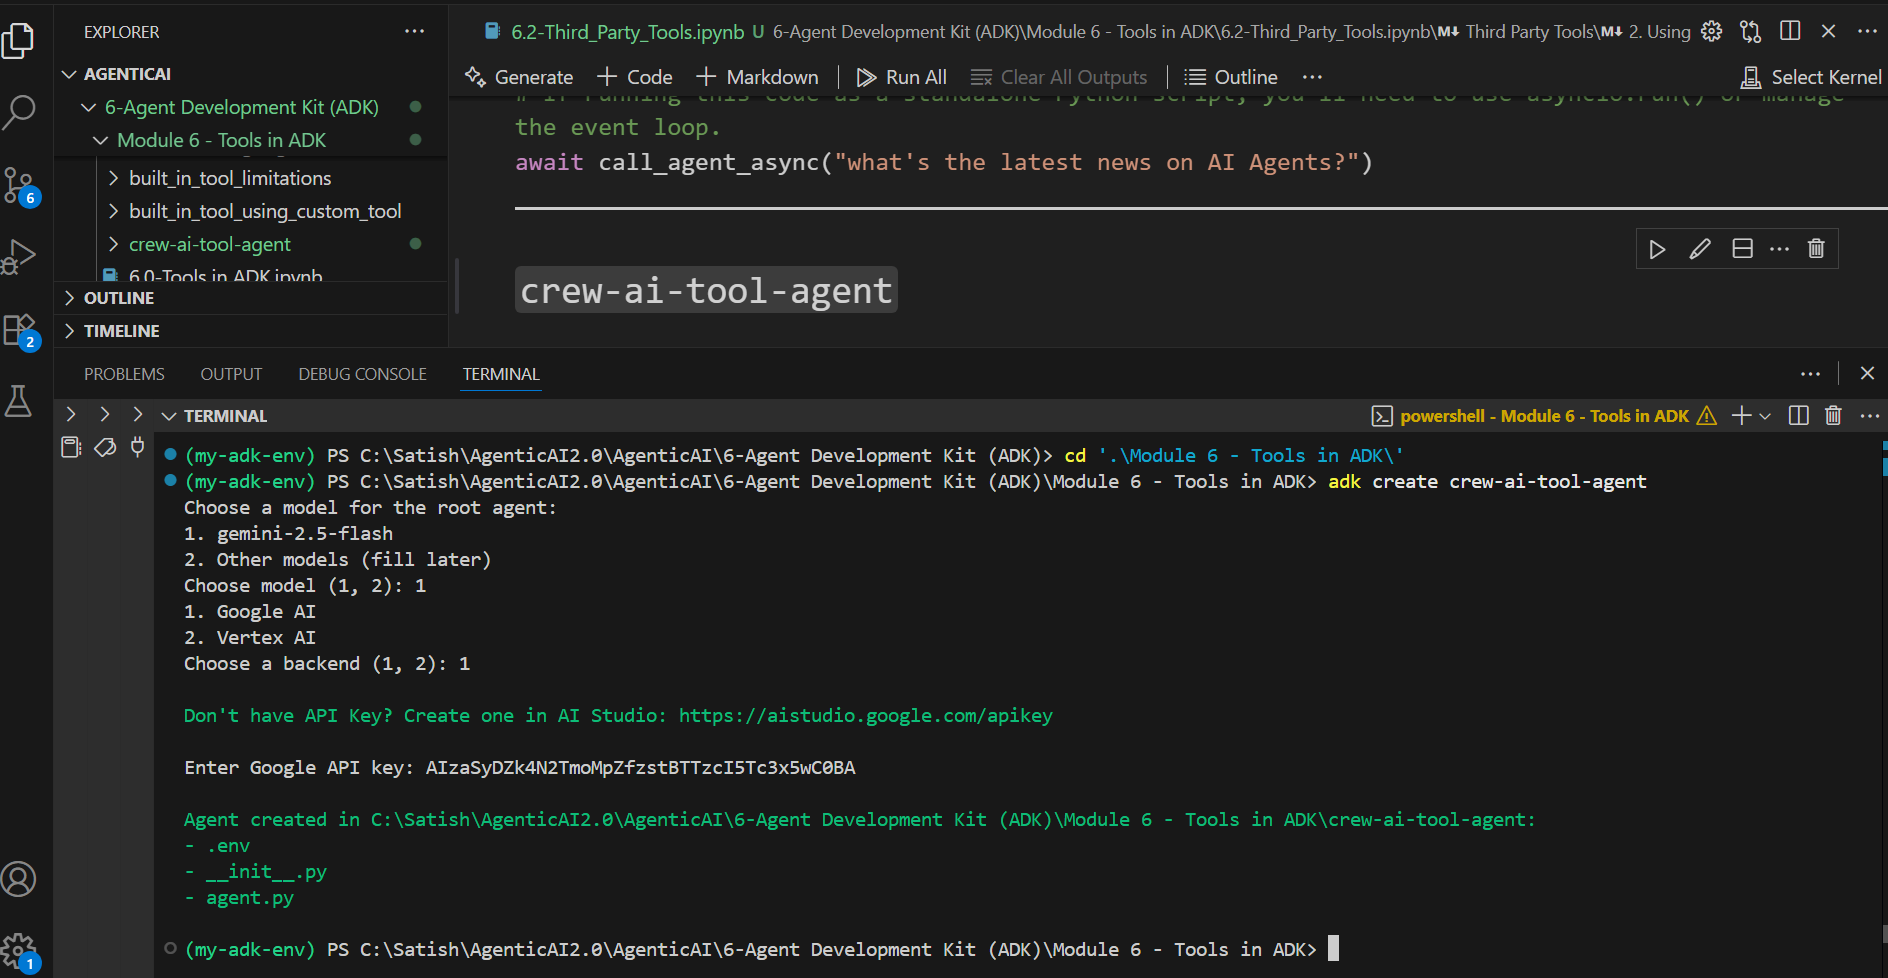 

#### [CrewAI-Google Serper Search](https://docs.crewai.com/en/tools/search-research/serperdevtool)
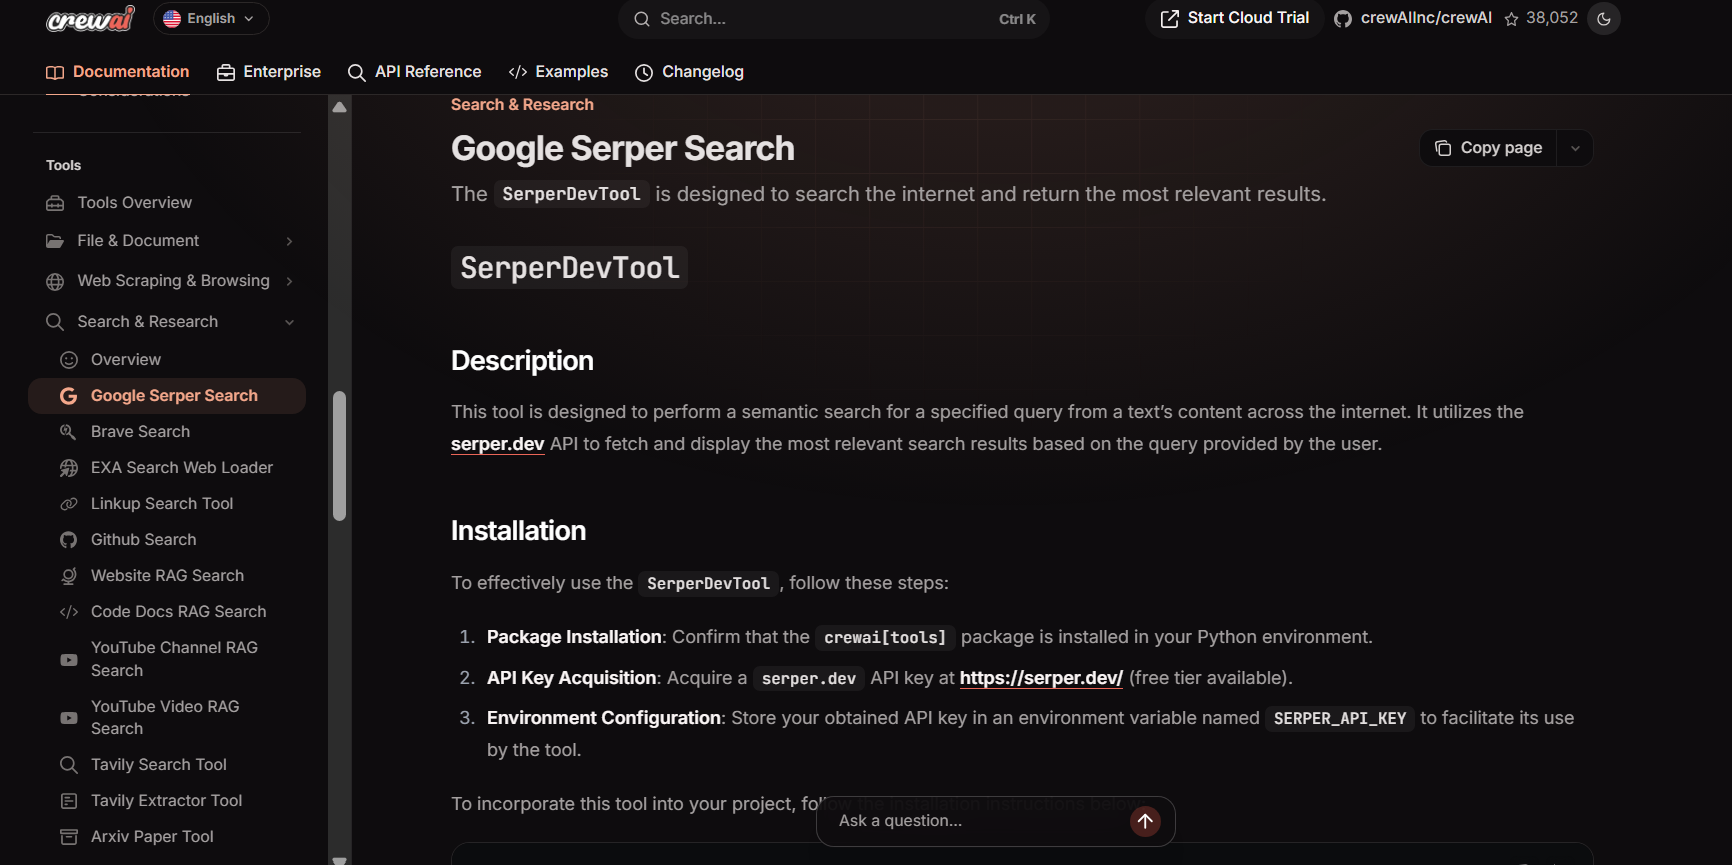

#### [Serper](https://serper.dev/)
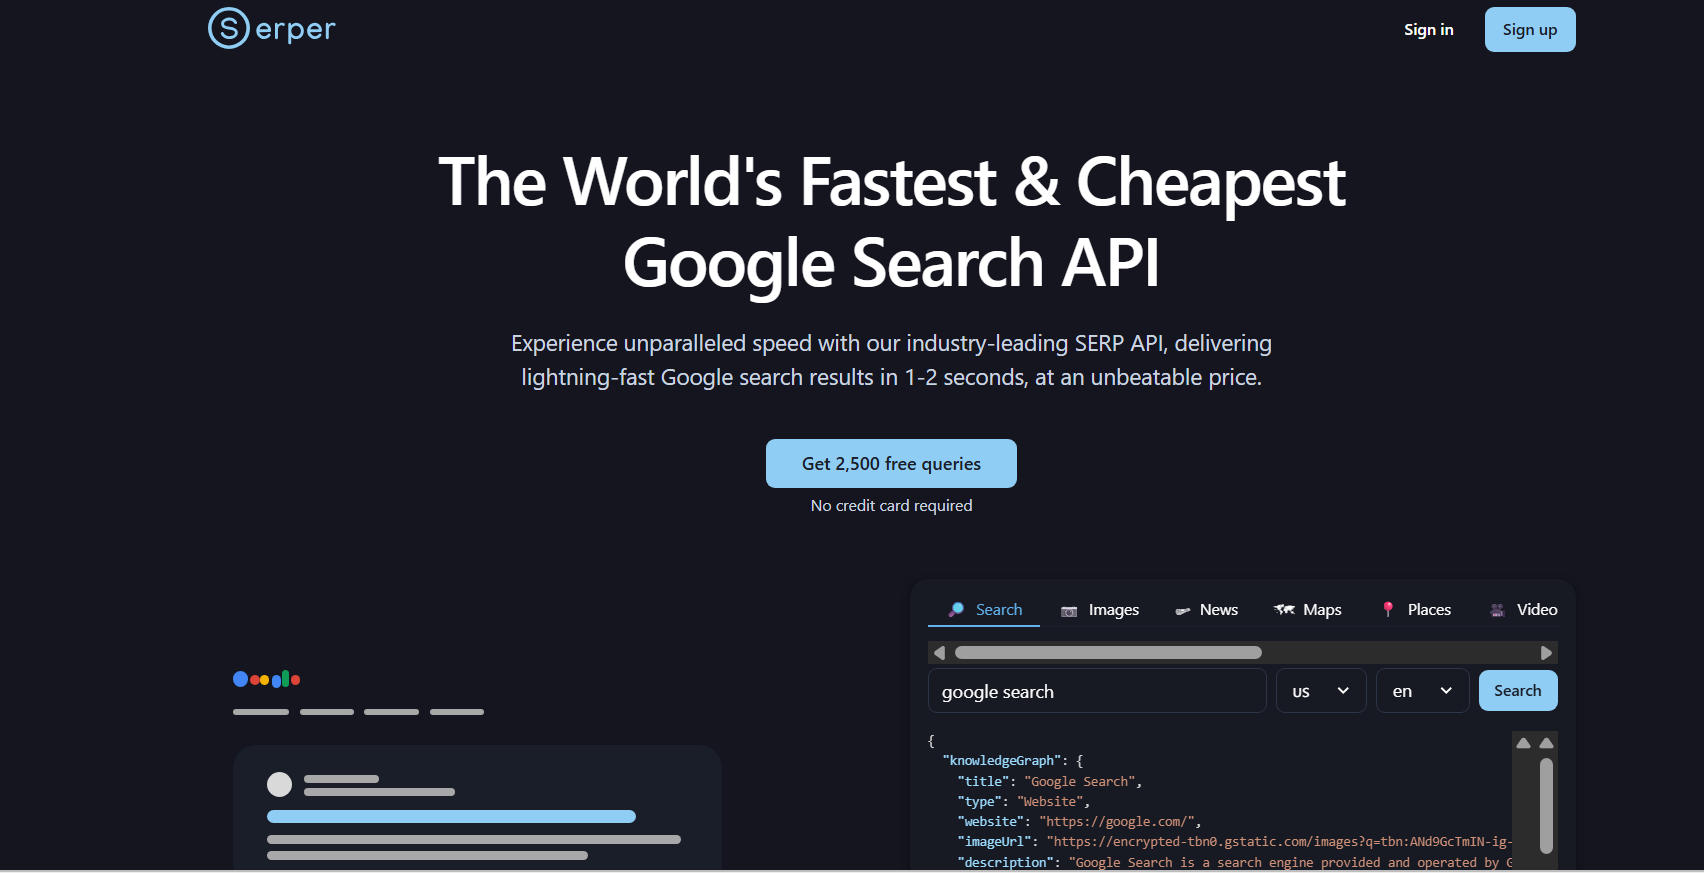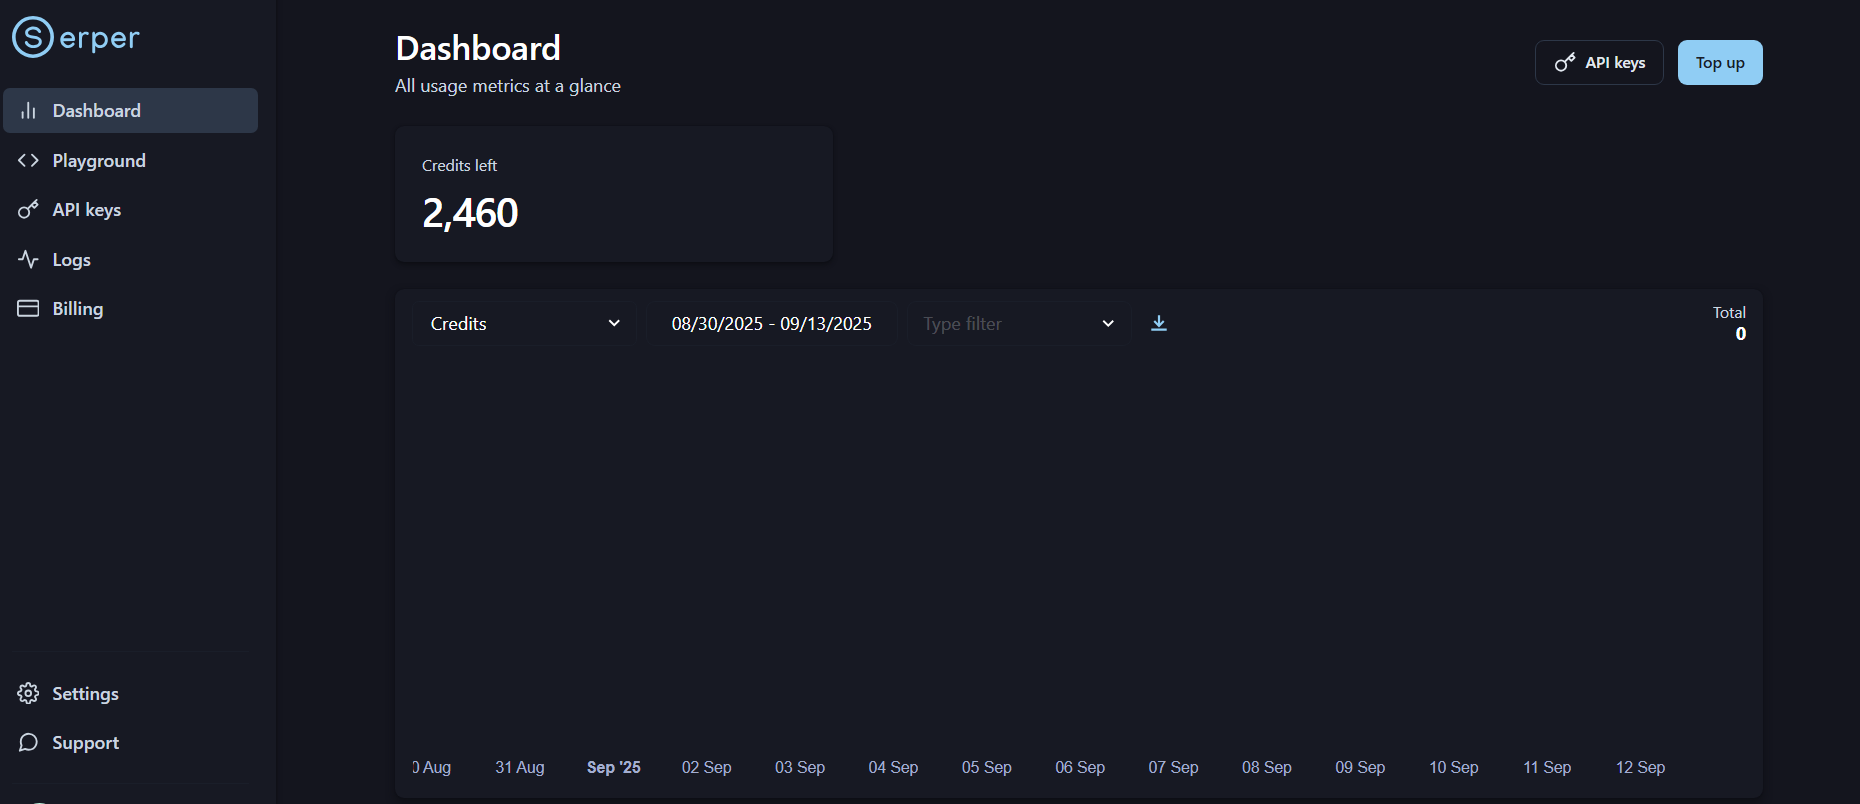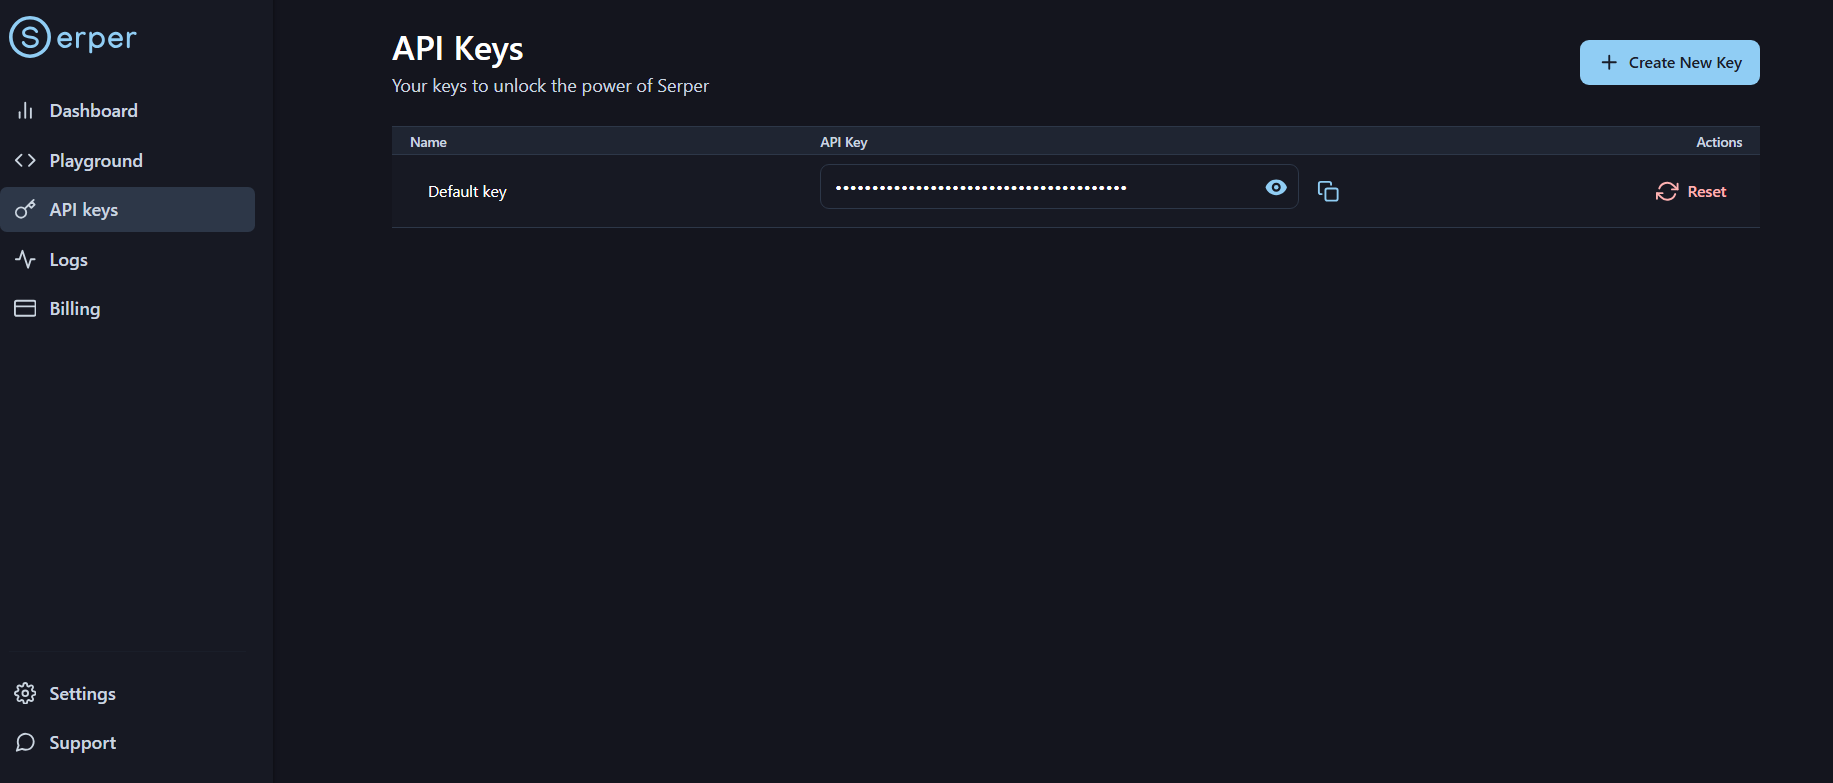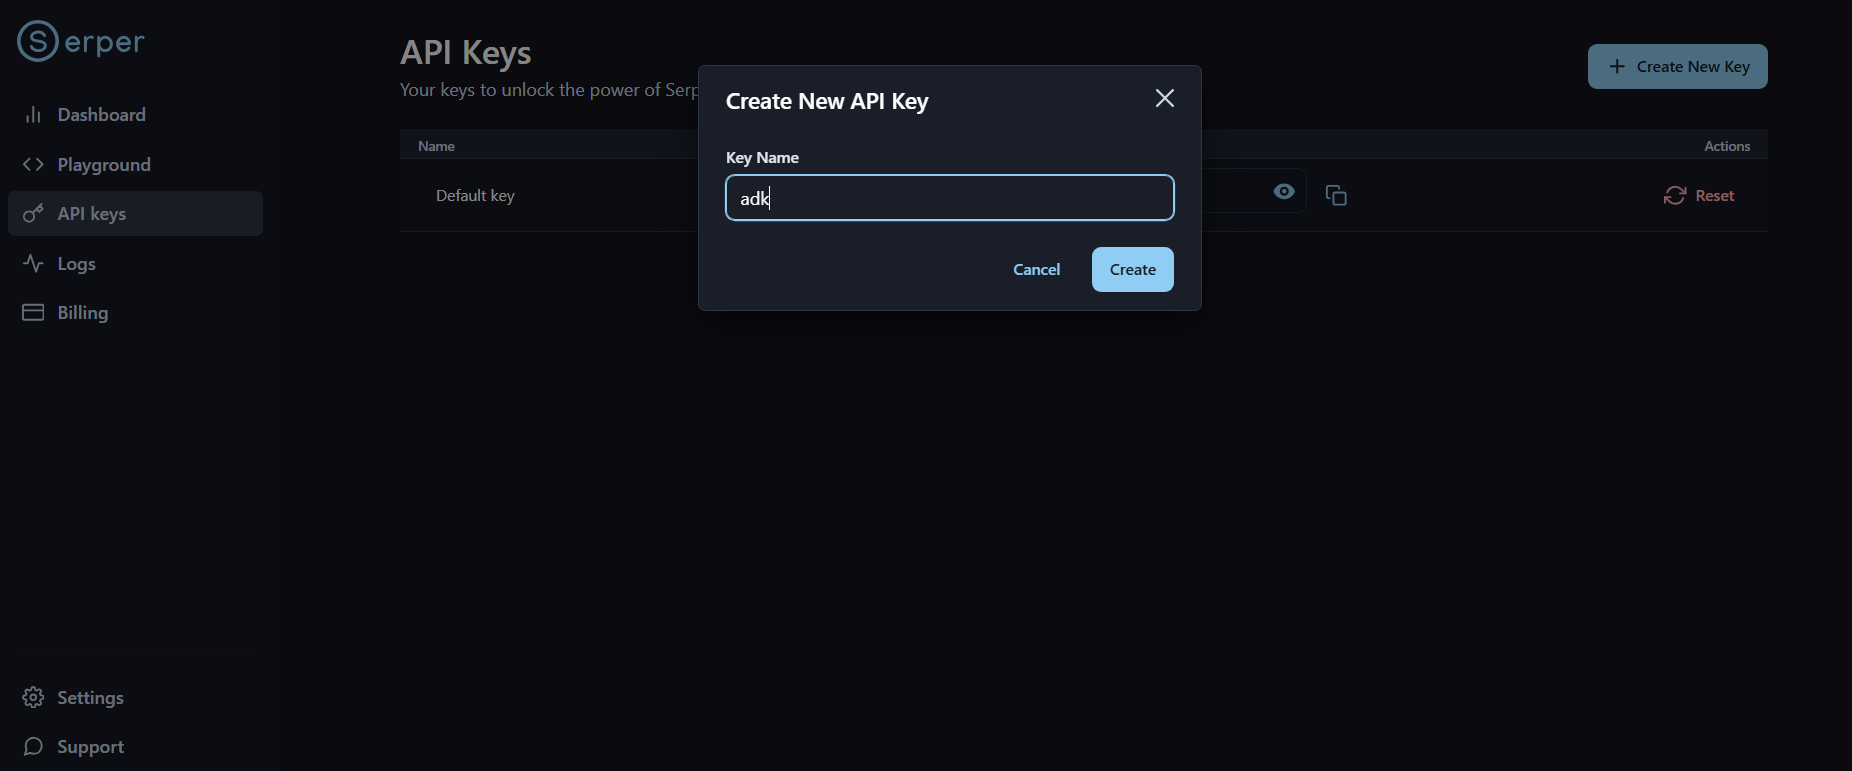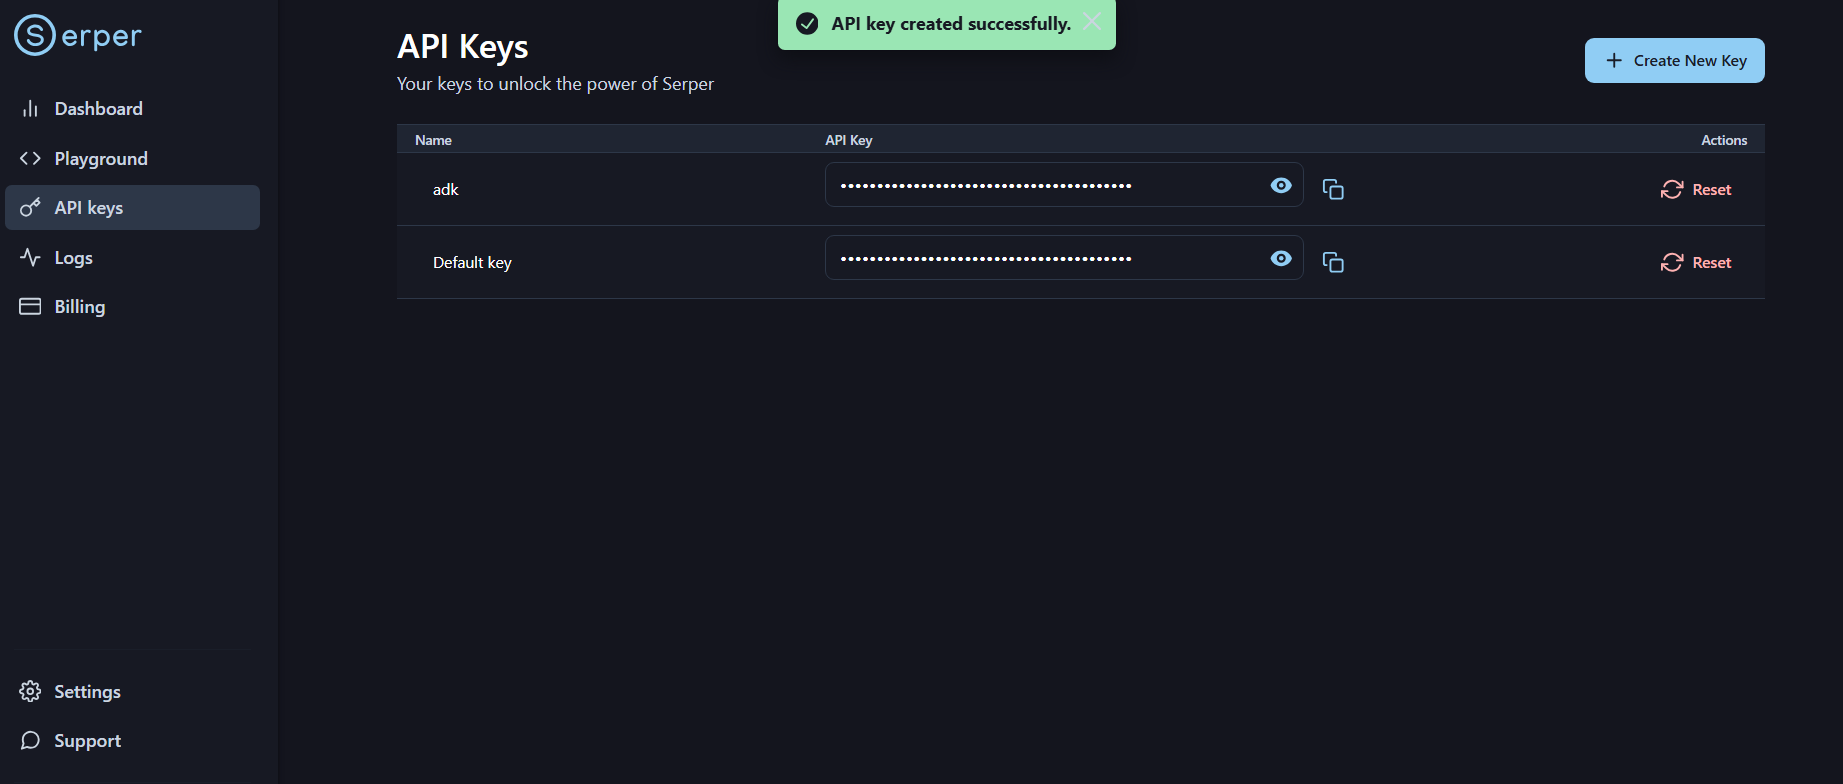

<hr>